# Fall Detection System - Methodology

## Complete Implementation from Training to Real-Time Inference

1. Dataset preprocessing and model training
2. Model evaluation on test data
3. Core inference functions and classes
4. Real-time web server implementation


## Section 1: Imports and Setup

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from keras import regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

import seaborn as sns

# Set style for visualizations
plt.style.use('seaborn-v0_8')

2026-01-18 15:11:54.288055: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Extract Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/drive/MyDrive/Edge AI Fall detection/Roboflow/Dataset.zip" -d "/content/Edge AI Fall detection/"

Mounted at /content/drive


## Section 2: Dataset and Preprocessing

### 2.1 Dataset Overview
- **Data Sources**: Roboflow datasets
- **Total Samples**: ~33,734 images
- **Split Ratio**: 70% Train / 20% Validation / 10% Test
- **Preprocessing**: Images resized to 128×128, normalized to [0,1], person crops extracted using YOLO bounding boxes with 10% margin

### 2.2 Data Generator
Custom data generator that:
- Loads images and corresponding YOLO-format label files
- Extracts person crops using bounding box coordinates
- Resizes crops to 128×128 pixels
- Normalizes pixel values to [0, 1] range
- Handles batch generation for training


In [ ]:
BASE_DIR = "/content/Edge AI Fall detection/content/Edge AI Fall detection/Unwanted Removed/"

def data_generator(split='train', pref_size=(128, 128), batch_size=32):
    """
    Generator that yields batches of cropped images and class labels.

    Folder structure:
      BASE_DIR/images/<split>/
      BASE_DIR/labels/<split>/

    For each image file, the generator reads the corresponding label file.
    Processes only the first bounding box per file.
    """
    img_dir = os.path.join(BASE_DIR, 'images', split)
    label_dir = os.path.join(BASE_DIR, 'labels', split)

    img_files = sorted(os.listdir(img_dir))
    label_files = sorted(os.listdir(label_dir))

    num_samples = len(img_files)

    while True:
        # Shuffle indices at the beginning of each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        for offset in range(0, num_samples, batch_size):
            batch_imgs = []
            batch_labels = []
            batch_indices = indices[offset:offset+batch_size]

            for idx in batch_indices:
                img_file = img_files[idx]
                label_file = label_files[idx]

                # Read the image and convert from BGR to RGB
                img_path = os.path.join(img_dir, img_file)
                img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                image_height, image_width, _ = img.shape

                label_path = os.path.join(label_dir, label_file)
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                if len(lines) == 0:
                    continue

                # Process only the first bounding box in the file
                line = lines[0]
                parts = line.split()
                if len(parts) < 5:
                    print(f"Warning: {label_file} does not have enough values: {line}")
                    continue
                class_label = int(parts[0])
                if len(parts) == 5:
                    # Standard YOLO format: <class> <x_center> <y_center> <width> <height>
                    x_center, y_center, width, height = map(float, parts[1:5])
                    xmin = int(x_center * image_width - (width * image_width) / 2)
                    ymin = int(y_center * image_height - (height * image_height) / 2)
                    crop_width = int(width * image_width)
                    crop_height = int(height * image_height)
                else:
                    # Extended format: <class> followed by multiple normalized coordinate pairs.
                    # Compute bounding box by taking the min and max of the coordinates.
                    coords = list(map(float, parts[1:]))
                    xs = [x * image_width for x in coords[0::2]]
                    ys = [y * image_height for y in coords[1::2]]
                    xmin, ymin = int(min(xs)), int(min(ys))
                    xmax, ymax = int(max(xs)), int(max(ys))
                    crop_width, crop_height = xmax - xmin, ymax - ymin

                # Ensure the crop indices are within image boundaries
                x_start, y_start = max(0, xmin), max(0, ymin)
                x_end, y_end = min(image_width, xmin + crop_width), min(image_height, ymin + crop_height)

                # Crop the image
                cropped = img[y_start:y_end, x_start:x_end]
                if cropped.size == 0:
                    print(f"Warning: empty crop for {img_file} with box {line}")
                    continue
                try:
                    # Resize crop to the preferred size
                    cropped_resized = cv2.resize(cropped, pref_size)
                except Exception as e:
                    print(f"Error resizing image {img_file}: {e}")
                    continue

                batch_imgs.append(cropped_resized)
                batch_labels.append(class_label)

            if batch_imgs:
                X_batch = np.array(batch_imgs, dtype=np.float32) / 255.0
                y_batch = np.array(batch_labels)
                yield X_batch, y_batch

## Create Dataset objects and Calculate Steps

In [ ]:
def count_samples(split='train'):
    img_dir = os.path.join(BASE_DIR, 'images', split)
    return len(os.listdir(img_dir))

BATCH_SIZE = 32
train_samples = count_samples('train')
val_samples   = count_samples('val')
test_samples  = count_samples('test')

steps_per_epoch = int(np.ceil(train_samples / BATCH_SIZE))
val_steps       = int(np.ceil(val_samples / BATCH_SIZE))
test_steps      = int(np.ceil(test_samples / BATCH_SIZE))

print(f"Train samples: {train_samples}, Steps per epoch: {steps_per_epoch}")
print(f"Validation samples: {val_samples}, Validation steps: {val_steps}")
print(f"Test samples: {test_samples}, Test steps: {test_steps}")


Train samples: 23756, Steps per epoch: 743
Validation samples: 6638, Validation steps: 208
Test samples: 3340, Test steps: 105


## Create Dataset objects from the generator for each split

In [ ]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator('train', batch_size=BATCH_SIZE),
    output_types=(tf.float32, tf.int32),
    output_shapes=([None, 128, 128, 3], [None])
).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator('val', batch_size=BATCH_SIZE),
    output_types=(tf.float32, tf.int32),
    output_shapes=([None, 128, 128, 3], [None])
).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator('test', batch_size=BATCH_SIZE),
    output_types=(tf.float32, tf.int32),
    output_shapes=([None, 128, 128, 3], [None])
).prefetch(tf.data.AUTOTUNE)

Instructions for updating:
Use output_signature instead
Instructions for updating:
Use output_signature instead


## Section 3: Model Architecture and Training

### 3.1 Model Architecture Justification

**Base Model: MobileNetV2**
- **Reason**: Lightweight, efficient architecture optimized for edge devices
- **Benefits**: 
  - Low computational cost (3.4M parameters)
  - Fast inference time
  - Pre-trained on ImageNet (transfer learning)
  - Depthwise separable convolutions reduce parameters

**Input Size: 128×128 pixels**
- **Reason**: Balance between detail preservation and computational efficiency
- **Benefits**:
  - Faster inference time
  - Sufficient resolution for fall detection task

**Architecture Components:**
- **GlobalAveragePooling2D**: Reduces spatial dimensions, prevents overfitting
- **Dense(128)**: Non-linear feature transformation with L2 regularization (0.001)
- **Dropout(0.5)**: Regularization to prevent overfitting
- **Dense(2)**: Binary classification output (Fall/Non-Fall)

### 3.2 Transfer Learning Strategy

**Layer Freezing Approach:**
- **Frozen Layers**: All layers except last 20 layers
- **Trainable Layers**: Last 20 layers + custom classification head
- **Rationale**: 
  - Early layers learn general features (edges, textures)
  - Later layers learn task-specific features
  - Fine-tuning only necessary layers saves computation
  - Prevents overfitting on small dataset

### 3.3 Training Configuration

- **Optimizer**: Adam with learning rate 1e-5 (low LR for fine-tuning)
- **Loss Function**: Sparse Categorical Cross entropy
- **Batch Size**: 32
- **Early Stopping**: Monitor validation loss, patience=3
- **Epochs**: 25 (with early stopping)


In [ ]:
# Load the MobileNetV2 base model with ImageNet weights
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze all layers first, then unfreeze the last 20 layers for fine-tuning
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# Set up early stopping callback to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 1,370,306 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

### 3.4 Model Training

In [ ]:
history = model.fit(
    train_dataset,
    epochs=25,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stop]
)

Epoch 1/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 683s 903ms/step - accuracy: 0.7017 - loss: 0.8249 - val_accuracy: 0.8499 - val_loss: 0.5813
Epoch 2/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 683s 920ms/step - accuracy: 0.8868 - loss: 0.5090 - val_accuracy: 0.9064 - val_loss: 0.4587
Epoch 3/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 683s 919ms/step - accuracy: 0.9205 - loss: 0.4340 - val_accuracy: 0.9308 - val_loss: 0.4063
Epoch 4/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 665s 895ms/step - accuracy: 0.9369 - loss: 0.3929 - val_accuracy: 0.9436 - val_loss: 0.3719
Epoch 5/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 684s 921ms/step - accuracy: 0.9485 - loss: 0.3594 - val_accuracy: 0.9509 - val_loss: 0.3505
Epoch 6/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 680s 915ms/step - accuracy: 0.9567 - loss: 0.3385 - val_accuracy: 0.9560 - val_loss: 0.3378
Epoch 7/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 677s 912ms/step - accuracy: 0.9614 - loss: 0.3216 - val_accuracy: 0.9592 - val_loss: 0.3273
Epoch 8/25
743/743 ━━━━━━━━━━━━━━━━━━━━ 665s 895ms/step - accuracy: 0.9661 -

#### Plot Training History

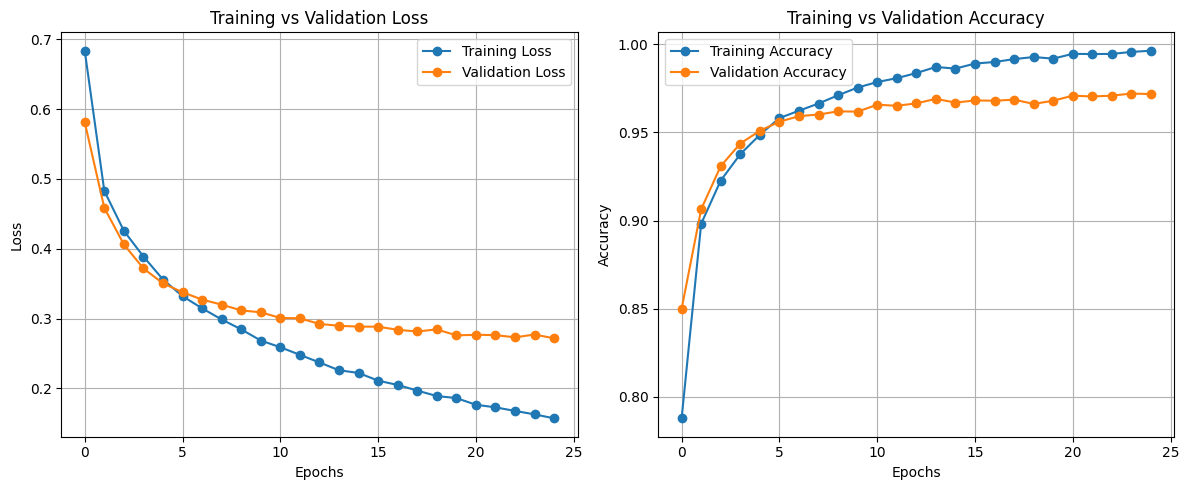

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label="Training Loss", marker='o')
plt.plot(val_loss, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Training Accuracy", marker='o')
plt.plot(val_acc, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### Save the Model

In [ ]:
model.save('/content/drive/MyDrive/Edge AI Fall detection/Roboflow/Fall-Detector.h5')

#### Evaluate the Model on the Test Set

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset, steps=test_steps)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 54s 481ms/step - accuracy: 0.9615 - loss: 0.3058
Test Loss: 0.2929, Test Accuracy: 0.9659


### 3.5 Model Quantization

The trained model is converted to TensorFlow Lite (TFLite) format with full integer quantization (int8) for edge deployment:

- **Benefits**: 
  - Reduced model size (~50% reduction: 20MB → 9MB)
  - Faster inference on edge devices
  - Lower memory usage
  - Hardware acceleration support


In [ ]:
def representative_dataset():
    image_size = (128, 128)
    samples = []

    # Take one batch from the test dataset for calibration
    for X_batch, _ in test_dataset.take(1):
        for i in range(min(250, X_batch.shape[0])):
            # Convert the tensor to a numpy array and add a batch dimension
            sample = np.expand_dims(X_batch[i].numpy(), axis=0)
            samples.append(sample)
    for sample in samples:
        yield [sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Set the optimization flag to default; this enables quantization optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Set the input and output tensors to int8 for quantized inference
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
converter.representative_dataset = representative_dataset

tflite_quant_model = converter.convert()
with open("/content/drive/MyDrive/Edge AI Fall detection/Roboflow/Fall-Detector-Lite.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("Fully integer quantized TFLite model saved as 'Fall-Detector-Lite.tflite'")

Saved artifact at '/tmp/tmpgd3zwzku'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137175888896144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175888892304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175888893264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175888891920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175888893072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175888892496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175866410384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175866410768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175866410576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137175866409232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1371758664119

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Fully integer quantized TFLite model saved as 'fall_detection_int8.tflite'


## Section 4: Model Evaluation on Test Data (Edge Deployment)

This section evaluates the **TFLite quantized model** on the test dataset (300 samples) to demonstrate edge deployment performance.

**Evaluation Metrics:**
- Confusion Matrix (TP, TN, FP, FN)
- Classification Report (Precision, Recall, F1-score)
- ROC Curve and AUC
- Precision-Recall Curve and Average Precision
- Per-class Accuracy
- Sample Predictions (6 images with actual vs predicted labels)


In [ ]:
tflite_model_path = "Fall-detector-lite.tflite"

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Get quantization parameters
input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']


def predict_tflite(images):
    """
    Run inference using TFLite model (for edge deployment).

    Args:
        images: Preprocessed images array (N, 128, 128, 3) normalized to [0, 1]

    Returns:
        predictions: Probability array (N, 2) for [Fall, Non-Fall]
    """
    predictions = []
    for img in images:
        # Quantize input
        if input_scale != 0:
            quantized_input = (img / input_scale + input_zero_point).astype(np.int8)
            quantized_input = np.clip(quantized_input, -128, 127)
        else:
            quantized_input = img

        # Run inference
        input_data = np.expand_dims(quantized_input, axis=0)
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])

        # Dequantize output
        if output_scale != 0:
            output_data = (output_data.astype(np.float32) - output_zero_point) * output_scale

        # Apply softmax
        probs = tf.nn.softmax(output_data, axis=-1).numpy().ravel()
        predictions.append(probs)

    return np.array(predictions)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [3]:
test_images_dir = "Test Data/images"
test_labels_dir = "Test Data/labels"

# Resize preserving aspect ratio
def resize_preserve_aspect(image, target_size=(128, 128)):
    h, w = image.shape[:2]
    target_w, target_h = target_size
    scale = min(target_h / h, target_w / w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    pad_h = (target_h - new_h) // 2
    pad_w = (target_w - new_w) // 2
    padded = cv2.copyMakeBorder(
        resized, pad_h, target_h - new_h - pad_h, pad_w, target_w - new_w - pad_w,
        cv2.BORDER_CONSTANT, value=[0, 0, 0]
    )
    return padded

# Preprocess with bounding box extraction
def preprocess_image_with_bbox(image_path, label_path=None, target_size=(128, 128),
                                margin_pct=0.1, preserve_aspect=True):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    img_h, img_w = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if label_path and os.path.exists(label_path):
        try:
            with open(label_path, 'r') as f:
                first_line = f.readline().strip()
                if first_line:
                    parts = first_line.split()
                    if len(parts) >= 5:
                        x_center_norm, y_center_norm, width_norm, height_norm = map(float, parts[1:5])
                        x_center = x_center_norm * img_w
                        y_center = y_center_norm * img_h
                        width = width_norm * img_w
                        height = height_norm * img_h
                        xmin = int(x_center - width / 2)
                        ymin = int(y_center - height / 2)
                        xmax = int(x_center + width / 2)
                        ymax = int(y_center + height / 2)
                        if margin_pct > 0:
                            crop_width = xmax - xmin
                            crop_height = ymax - ymin
                            x_margin = int(crop_width * margin_pct)
                            y_margin = int(crop_height * margin_pct)
                            xmin = max(0, xmin - x_margin)
                            ymin = max(0, ymin - y_margin)
                            xmax = min(img_w, xmax + x_margin)
                            ymax = min(img_h, ymax + y_margin)
                        person_crop = img_rgb[ymin:ymax, xmin:xmax]
                        if person_crop.size == 0:
                            person_crop = img_rgb
                    else:
                        person_crop = img_rgb
                else:
                    person_crop = img_rgb
        except Exception as e:
            person_crop = img_rgb
    else:
        person_crop = img_rgb

    if preserve_aspect:
        resized = resize_preserve_aspect(person_crop, target_size)
    else:
        resized = cv2.resize(person_crop, target_size)

    normalized = resized.astype(np.float32) / 255.0
    return normalized

def load_test_dataset(test_images_dir, test_labels_dir=None, target_size=(128, 128),
                     use_bbox=True, margin_pct=0.1):
    images = []
    labels = []
    image_files = sorted([f for f in os.listdir(test_images_dir)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    for img_file in image_files:
        img_path = os.path.join(test_images_dir, img_file)
        try:
            label_path = None
            if test_labels_dir:
                label_file = os.path.splitext(img_file)[0] + '.txt'
                label_path = os.path.join(test_labels_dir, label_file)

            if use_bbox and label_path and os.path.exists(label_path):
                img_processed = preprocess_image_with_bbox(
                    img_path, label_path, target_size, margin_pct=margin_pct
                )
            else:
                img = cv2.imread(img_path)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = resize_preserve_aspect(img_rgb, target_size)
                img_processed = img_resized.astype(np.float32) / 255.0

            images.append(img_processed)

            if test_labels_dir and label_path and os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    first_line = f.readline().strip()
                    if first_line:
                        class_label = int(first_line.split()[0])
                        if class_label in [0, 1]:
                            labels.append(class_label)
                        else:
                            continue
                    else:
                        continue
            else:
                labels.append(None)
        except Exception as e:
            continue

    images = np.array(images)
    labels = np.array(labels) if None not in labels else None
    return images, labels

# Load test dataset
if os.path.exists(test_images_dir):
    test_images, test_labels = load_test_dataset(
        test_images_dir, test_labels_dir, use_bbox=True, margin_pct=0.1
    )
    print(f"Loaded {len(test_images)} test images")
    if test_labels is not None:
        print(f"  Fall (0): {np.sum(test_labels == 0)}")
        print(f"  Non-Fall (1): {np.sum(test_labels == 1)}")
else:
    print(f"Test data directory not found: {test_images_dir}")
    test_images, test_labels = None, None


Loaded 300 test images
  Fall (0): 152
  Non-Fall (1): 148


In [4]:
# Generate predictions using TFLite model (edge deployment format)
if test_images is not None and len(test_images) > 0:
    y_pred_proba = predict_tflite(test_images)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    y_pred_fall_proba = y_pred_proba[:, 1]
    print(f"Predictions generated using TFLite quantized model")
else:
    print("No test images loaded")
    y_pred_proba, y_pred_classes, y_pred_fall_proba = None, None, None


Predictions generated using TFLite quantized model


#### Confusion Matrix

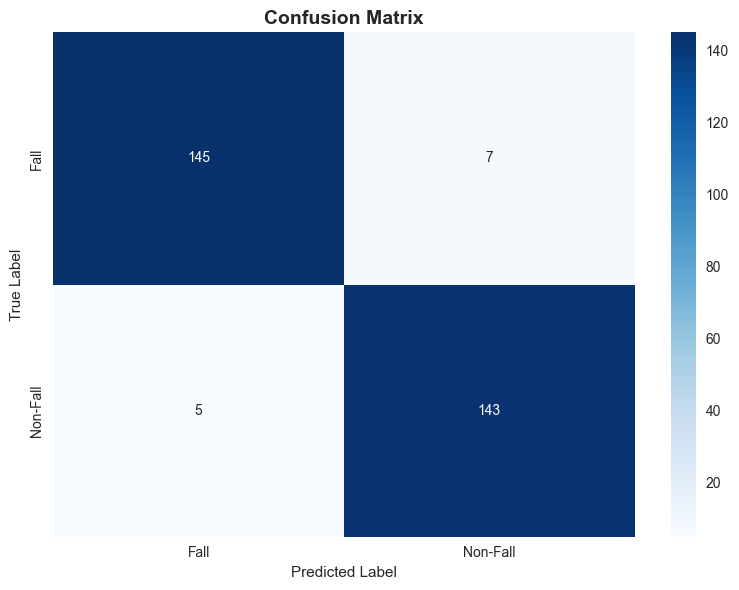


Metrics:
  Accuracy:  0.9600 (96.00%)
  Precision: 0.9667
  Recall:    0.9539
  F1-Score:  0.9603


In [5]:

if test_labels is not None and y_pred_classes is not None:
    cm = confusion_matrix(test_labels, y_pred_classes, labels=[0, 1])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fall', 'Non-Fall'],
                yticklabels=['Fall', 'Non-Fall'])
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    TP = cm[0, 0]  # True Fall predicted as Fall
    FN = cm[0, 1]  # True Fall predicted as Non-Fall
    FP = cm[1, 0]  # True Non-Fall predicted as Fall
    TN = cm[1, 1]  # True Non-Fall predicted as Non-Fall

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nMetrics:")
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")


#### ROC Curve and Precision-Recall Curve

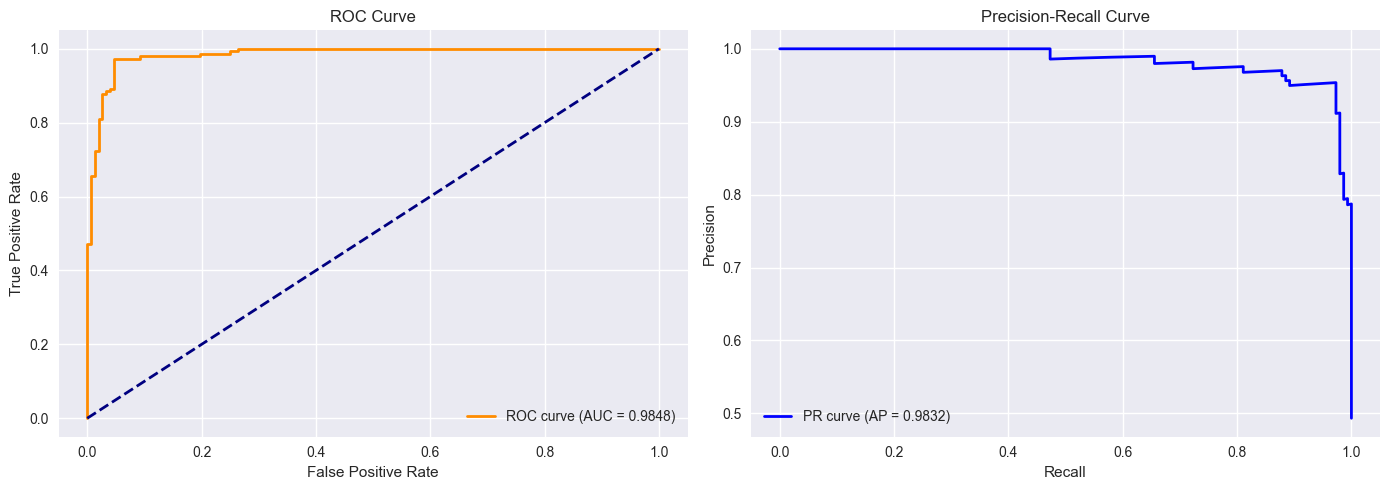

ROC AUC: 0.9848
Average Precision: 0.9832


In [6]:
if test_labels is not None and y_pred_fall_proba is not None:
    # ROC Curve
    fpr, tpr, _ = roc_curve(test_labels, y_pred_fall_proba)
    roc_auc = auc(fpr, tpr)

    # Precision-Recall Curve
    precision_curve, recall_curve, _ = precision_recall_curve(test_labels, y_pred_fall_proba)
    pr_auc = average_precision_score(test_labels, y_pred_fall_proba)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC Curve
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve')
    axes[0].legend(loc="lower right")
    axes[0].grid(True)

    # Precision-Recall Curve
    axes[1].plot(recall_curve, precision_curve, color='blue', lw=2,
                 label=f'PR curve (AP = {pr_auc:.4f})')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend(loc="lower left")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Average Precision: {pr_auc:.4f}")

## Classification Report

In [ ]:
if test_labels is not None and y_pred_classes is not None:
    print("=" * 70)
    print("CLASSIFICATION REPORT")
    print("=" * 70)
    report = classification_report(
        test_labels,
        y_pred_classes,
        target_names=['Non-Fall', 'Fall'],
        digits=4,
        output_dict=True
    )

    # Print the text report
    report_text = classification_report(
        test_labels,
        y_pred_classes,
        target_names=['Non-Fall', 'Fall'],
        digits=4
    )
    print(report_text)
    print("=" * 70)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Non-Fall     0.9667    0.9539    0.9603       152
        Fall     0.9533    0.9662    0.9597       148

    accuracy                         0.9600       300
   macro avg     0.9600    0.9601    0.9600       300
weighted avg     0.9601    0.9600    0.9600       300



### Display 6 sample images with predictions

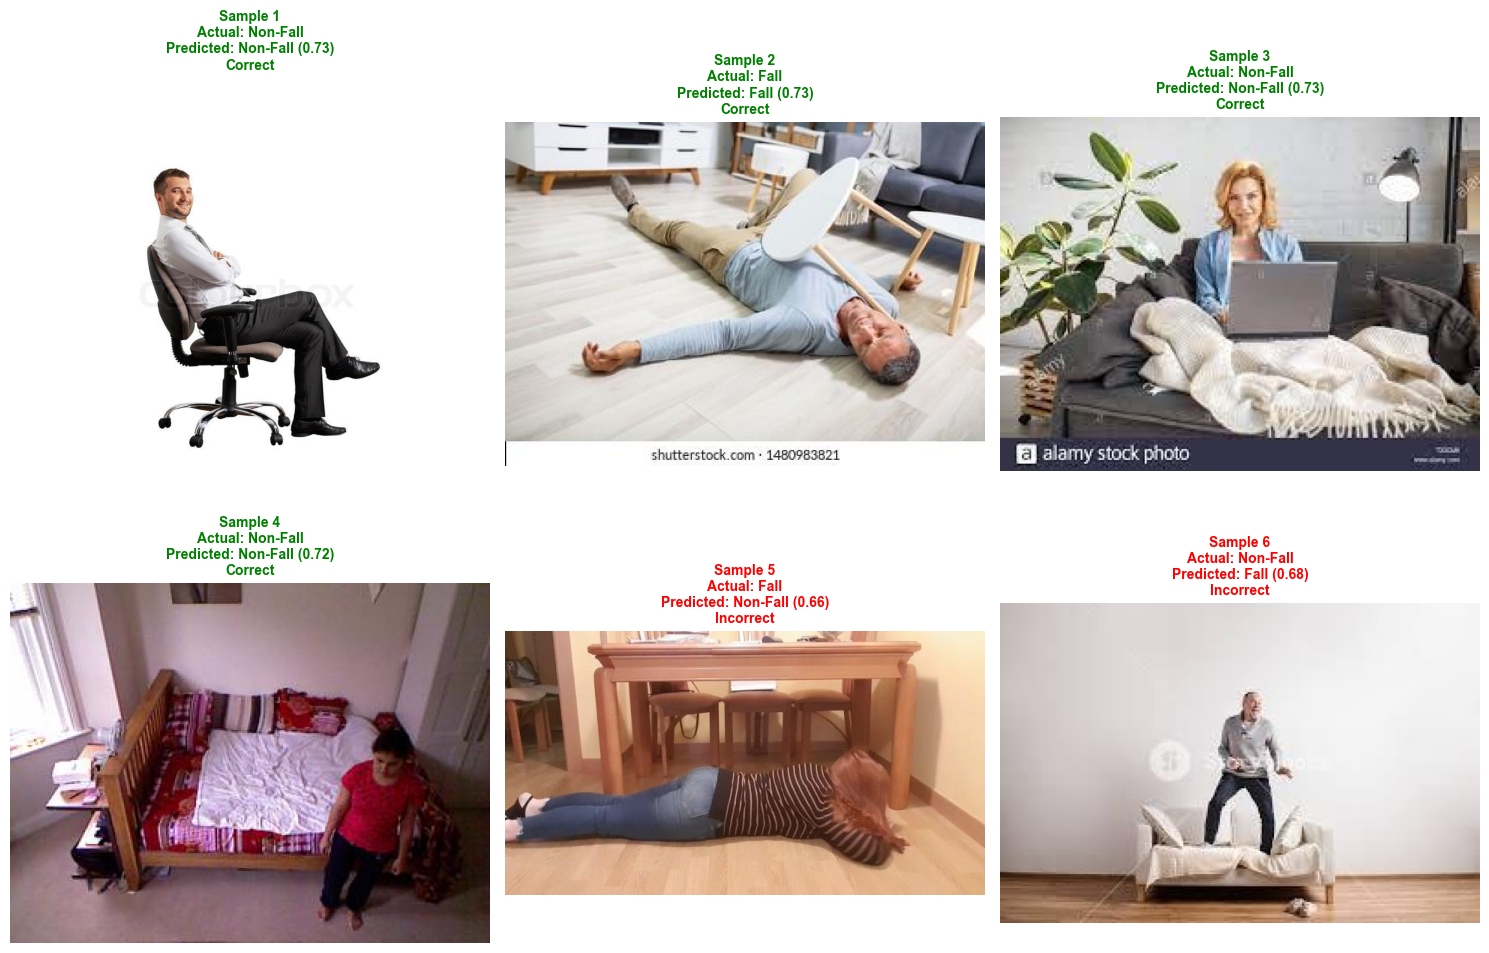

In [ ]:
if test_images is not None and test_labels is not None and y_pred_classes is not None:
    n_samples = min(6, len(test_images))

    image_files = sorted([f for f in os.listdir(test_images_dir)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[:len(test_images)]

    # Select mix of correct and incorrect predictions
    correct_indices = [i for i in range(len(test_labels))
                       if test_labels[i] == y_pred_classes[i]]
    incorrect_indices = [i for i in range(len(test_labels))
                        if test_labels[i] != y_pred_classes[i]]


    np.random.seed(None)
    np.random.shuffle(correct_indices)
    np.random.shuffle(incorrect_indices)

    n_correct = min(4, len(correct_indices))
    n_incorrect = min(2, len(incorrect_indices))

    selected_correct = np.random.choice(correct_indices, size=n_correct, replace=False).tolist() if len(correct_indices) > 0 else []
    selected_incorrect = np.random.choice(incorrect_indices, size=n_incorrect, replace=False).tolist() if len(incorrect_indices) > 0 else []

    selected_indices = selected_correct + selected_incorrect
    selected_indices = selected_indices[:n_samples]

    # If no enough samples, fill with random indices
    if len(selected_indices) < n_samples:
        remaining = n_samples - len(selected_indices)
        all_indices = list(range(len(test_images)))
        available = [i for i in all_indices if i not in selected_indices]
        if len(available) > 0:
            additional = np.random.choice(available, size=min(remaining, len(available)), replace=False).tolist()
            selected_indices.extend(additional)
        else:
            selected_indices = list(range(n_samples))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    class_names = ['Fall', 'Non-Fall']

    for idx, sample_idx in enumerate(selected_indices):
        # Load original image for display
        img_file = image_files[sample_idx]
        img_path = os.path.join(test_images_dir, img_file)
        original_img = cv2.imread(img_path)
        if original_img is not None:
            original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        else:
            original_img = (test_images[sample_idx] * 255).astype(np.uint8)

        actual_label = test_labels[sample_idx]
        pred_label = y_pred_classes[sample_idx]
        pred_prob = y_pred_proba[sample_idx]
        confidence = pred_prob[pred_label]

        axes[idx].imshow(original_img)
        axes[idx].axis('off')

        color = 'green' if actual_label == pred_label else 'red'
        status = 'Correct' if actual_label == pred_label else 'Incorrect'

        title = f"Sample {idx+1}\n"
        title += f"Actual: {class_names[actual_label]}\n"
        title += f"Predicted: {class_names[pred_label]} ({confidence:.2f})\n"
        title += f"{status}"

        axes[idx].set_title(title, fontsize=10, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot display samples: Test data not loaded")


# Prototype Demonstration

## Complete Video Processing Pipeline

This prototype demonstrates the complete fall detection system:
1. **Input**: MP4 video file
2. **Processing**: Frame-by-frame detection using core functions
3. **Output**: Annotated video with bounding boxes and metrics

**Components Demonstrated:**
- YOLO person detection
- CNN-based fall classification (TFLite)
- PSI (Pose Stability Index) calculation
- Multi-modal fusion
- Person tracking


In [3]:
import sys
from pathlib import Path
import time
from tqdm import tqdm

# Add parent directory to path to import core functions
sys.path.append(str(Path().absolute().parent))
from fall_detector_core import (
    FallDetectorConfig,
    load_tflite_model,
    load_yolo_model,
    load_mediapipe_pose,
    process_frame_for_display,
    FallDetector,
)

# CONFIGURATION
print("#" * 70)
print("VIDEO PROCESSING PROTOTYPE")
print("#" * 70)


INPUT_VIDEO = "test_video1.mp4"
OUTPUT_VIDEO = "output_annotated_video1.mp4"
OUTPUT_DIR = "prototype_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Check if input video exists
if not os.path.exists(INPUT_VIDEO):
    print(f"\nInput video not found: {INPUT_VIDEO}")


# LOAD MODELS

print("\nStep 1: Loading Models...")
print("-" * 50)

config = FallDetectorConfig()

# Load TFLite model
print("\nLoading TFLite model...")
try:
    interpreter, input_details, output_details = load_tflite_model(config.tflite_path)
    print(f"  TFLite model loaded: {config.tflite_path}")
except Exception as e:
    print(f"  Error loading TFLite model: {e}")
    raise

# Load YOLO model
print("\nLoading YOLO model...")
try:
    yolo, device = load_yolo_model(config.yolo_pt)
    print(f"  YOLO model loaded: {config.yolo_pt}")
except Exception as e:
    print(f"  Error loading YOLO model: {e}")
    raise

# Load MediaPipe
print("\nLoading MediaPipe pose detector...")
try:
    pose_detector, mp_pose = load_mediapipe_pose(config)
    print("  MediaPipe pose detector loaded")
except Exception as e:
    print(f"  Error loading MediaPipe: {e}")
    raise

# Initialize Fall Detector
detector = FallDetector(config)
print("Fall detector initialized")

print("\nAll models loaded successfully!")

# OPEN INPUT VIDEO
print("\nStep 2: Opening Input Video...")
print("-" * 50)

cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    print(f"Error: Could not open video: {INPUT_VIDEO}")
    raise ValueError(f"Cannot open video file: {INPUT_VIDEO}")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps if fps > 0 else 0

print(f"  Video opened successfully")
print(f"  Resolution: {width}×{height}")
print(f"  FPS: {fps:.2f}")
print(f"  Total frames: {total_frames}")
print(f"  Duration: {duration:.2f} seconds")


# SETUP OUTPUT VIDEO
print("\nStep 3: Setting Up Output Video...")
print("-" * 50)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps if fps > 0 else 30.0, (width, height))
print(f"  Output video writer initialized: {OUTPUT_VIDEO}")


# PROCESS VIDEO FRAME BY FRAME
print("\nStep 4: Processing Video Frames...")
print("-" * 50)
print("Processing each frame with:")
print("  - YOLO person detection")
print("  - CNN fall classification")
print("  - PSI calculation")
print("  - Multi-modal fusion")
print("  - Temporal smoothing")
print("")

# Statistics
frame_count = 0
fall_events = 0
last_fall_state = False
processing_times = []
start_time = time.time()

# Tracking for visualization
last_detections = None
session_start_time = time.time()

# Progress bar
pbar = tqdm(total=total_frames, desc="Processing frames", unit="frame")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    frame_start_time = time.time()

    # Calculate timestamp
    timestamp = (frame_count - 1) / fps if fps > 0 else frame_count / 30.0

    # Process frame using core function
    result = process_frame_for_display(
        frame,
        timestamp,
        interpreter,
        input_details,
        output_details,
        yolo,
        pose_detector,
        mp_pose,
        detector,
        config,
        fps=fps,
        frame_counter=frame_count,
        last_detections=last_detections,
    )

    (
        annotated_frame,
        fused_prob,
        psi_val,
        cnn_prob,
        fall_flag,
        new_detections,
        saved_file,
    ) = result

    # Update tracking
    last_detections = new_detections

    # Track fall events
    current_fall_state = fall_flag
    if current_fall_state and not last_fall_state:
        fall_events += 1
        print(f"\n🚨 Fall event #{fall_events} detected at frame {frame_count} (t={timestamp:.2f}s)")
    last_fall_state = current_fall_state

    # Convert RGB to BGR for video writing
    annotated_frame_bgr = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)

    # Write frame to output video
    out.write(annotated_frame_bgr)

    # Track processing time
    processing_time = time.time() - frame_start_time
    processing_times.append(processing_time)

    # Update progress bar
    pbar.update(1)
    pbar.set_postfix({
        'Falls': fall_events,
        'FPS': f'{1.0/processing_time:.1f}' if processing_time > 0 else 'N/A'
    })

pbar.close()

# FINALIZE AND DISPLAY RESULTS
print("\n" + "#" * 50)
print("PROCESSING COMPLETE")
print("#" * 50)

# Release resources
cap.release()
out.release()

# Calculate statistics
total_processing_time = time.time() - start_time
avg_processing_time = np.mean(processing_times) if processing_times else 0
avg_fps = 1.0 / avg_processing_time if avg_processing_time > 0 else 0

print(f"\nProcessing Statistics:")
print(f"  Total frames processed: {frame_count}")
print(f"  Total processing time: {total_processing_time:.2f} seconds")
print(f"  Average processing time per frame: {avg_processing_time*1000:.2f} ms")
print(f"  Average processing FPS: {avg_fps:.2f}")
print(f"  Fall events detected: {fall_events}")
print(f"  Fall detection rate: {fall_events/duration:.2f} falls/second" if duration > 0 else "  Fall detection rate: N/A")

print(f"\nOutput Files:")
print(f"  Annotated video: {OUTPUT_VIDEO}")
if os.path.exists(OUTPUT_VIDEO):
    file_size = os.path.getsize(OUTPUT_VIDEO) / (1024 * 1024)  # MB
    print(f"  File size: {file_size:.2f} MB")

print(f"\nPrototype demonstration complete!")
print(f"  Open '{OUTPUT_VIDEO}' to view the annotated video with:")
print(f"  - Person bounding boxes (YOLO)")
print(f"  - Fall probability metrics")
print(f"  - PSI scores")
print(f"  - CNN probabilities")
print(f"  - Fall alerts and timestamps")


######################################################################
VIDEO PROCESSING PROTOTYPE
######################################################################

Step 1: Loading Models...
--------------------------------------------------

Loading TFLite model...
  TFLite model loaded: Fall-detector-lite.tflite

Loading YOLO model...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Using cache found in /Users/Muaadh Nazly/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-3-6 Python-3.10.0 torch-2.2.2 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


  YOLO model loaded: yolov5s.pt

Loading MediaPipe pose detector...


I0000 00:00:1768724816.989662 6812278 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-18.8.16), renderer: Intel(R) Iris(TM) Graphics 6100
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


  MediaPipe pose detector loaded
Fall detector initialized

All models loaded successfully!

Step 2: Opening Input Video...
--------------------------------------------------
  Video opened successfully
  Resolution: 360×640
  FPS: 30.00
  Total frames: 232
  Duration: 7.73 seconds

Step 3: Setting Up Output Video...
--------------------------------------------------
  Output video writer initialized: output_annotated_video1.mp4

Step 4: Processing Video Frames...
--------------------------------------------------
Processing each frame with:
  - YOLO person detection
  - CNN fall classification
  - PSI calculation
  - Multi-modal fusion
  - Temporal smoothing



...

💾 Saved fall capture for person 0: fall_captures/fall_capture_01-18_13-57-07_person0.jpg (2 saves remaining before cooldown)

🚨 Fall event #3 detected at frame 93 (t=3.07s)


Processing frames:  42%|████▏     | 98/232 [00:10<00:12, 10.83frame/s, Falls=4, FPS=15.3]


🚨 Fall event #4 detected at frame 96 (t=3.17s)


Processing frames:  78%|███████▊  | 180/232 [00:19<00:05,  9.26frame/s, Falls=4, FPS=5.2] 


##################################################
PROCESSING COMPLETE
##################################################

Processing Statistics:
  Total frames processed: 180
  Total processing time: 19.60 seconds
  Average processing time per frame: 101.28 ms
  Average processing FPS: 9.87
  Fall events detected: 4
  Fall detection rate: 0.52 falls/second

Output Files:
  Annotated video: output_annotated_video1.mp4
  File size: 3.89 MB

Prototype demonstration complete!
  Open 'output_annotated_video1.mp4' to view the annotated video with:
  - Person bounding boxes (YOLO)
  - Fall probability metrics
  - PSI scores
  - CNN probabilities
  - Fall alerts and timestamps


## Benchmark: CNN Only, PSI Only, and Fused Configurations

This section benchmarks the system with three different configurations:
1. **CNN Only** (100% CNN, 0% PSI)
2. **PSI Only** (0% CNN, 100% PSI)
3. **Fused** (65% CNN, 35% PSI)



In [ ]:
print("#" * 70)
print("Benchmark: CNN ONLY, PSI ONLY, AND FUSED CONFIGURATIONS")
print("#" * 70)

INPUT_VIDEOS = ["test_video1.mp4", "test_video2.mp4"]

# Configurations to test
CONFIGURATIONS = {
    "CNN Only": {"cnn_weight": 1.0, "psi_weight": 0.0},
    "PSI Only": {"cnn_weight": 0.0, "psi_weight": 1.0},
    "Fused": {"cnn_weight": 0.65, "psi_weight": 0.35},
}

# LOAD MODELS
print("\nStep 1: Loading Models...")
print("-" * 50)
base_config = FallDetectorConfig()

print("Loading TFLite model...")
try:
    interpreter, input_details, output_details = load_tflite_model(base_config.tflite_path)
    print(f"TFLite model loaded: {base_config.tflite_path}")
except Exception as e:
    print(f"Error loading TFLite model: {e}")
    raise

print("Loading YOLO model...")
try:
    yolo, device = load_yolo_model(base_config.yolo_pt)
    print(f"YOLO model loaded: {base_config.yolo_pt}")
except Exception as e:
    print(f"Error loading YOLO model: {e}")
    raise

print("Loading MediaPipe pose detector...")
try:
    pose_detector, mp_pose = load_mediapipe_pose(base_config)
    print("MediaPipe pose detector loaded")
except Exception as e:
    print(f"Error loading MediaPipe: {e}")
    raise

print("\nAll models loaded successfully!")

# PROCESS EACH VIDEO WITH EACH CONFIGURATION
print("\n" + "#" * 50)
print("PROCESSING VIDEOS")
print("#" * 50)

all_results = {}

for input_video in INPUT_VIDEOS:
    if not os.path.exists(input_video):
        print(f"\nVideo not found: {input_video}, skipping...")
        continue

    print(f"\nProcessing: {input_video}")
    print("-" * 50)

    # Open video to get properties
    cap = cv2.VideoCapture(input_video)
    if not cap.isOpened():
        print(f"Error: Could not open video: {input_video}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps > 0 else 0

    print(f"  Resolution: {width}×{height}")
    print(f"  FPS: {fps:.2f}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {duration:.2f} seconds")

    video_results = {}

    # Process with each configuration
    for config_name, weights in CONFIGURATIONS.items():
        print(f"\nConfiguration: {config_name}")
        print(f"CNN Weight: {weights['cnn_weight']:.2f}, PSI Weight: {weights['psi_weight']:.2f}")

        # Create config with specific weights
        config = FallDetectorConfig(
            cnn_weight=weights['cnn_weight'],
            psi_weight=weights['psi_weight']
        )

        # Initialize Fall Detector for this configuration
        detector = FallDetector(config)

        video_basename = os.path.splitext(input_video)[0]
        output_video = f"{video_basename}_{config_name.replace(' ', '_')}.mp4"

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_video, fourcc, fps if fps > 0 else 30.0, (width, height))

        # Reset video to beginning
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

        # Statistics
        frame_count = 0
        fall_events = 0
        last_fall_state = False
        processing_times = []
        start_time = time.time()

        # Tracking
        last_detections = None

        # Progress bar
        pbar = tqdm(total=total_frames, desc=f"\tProcessing {config_name}", unit="frame", leave=False)

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_count += 1
            frame_start_time = time.time()

            # Calculate timestamp
            timestamp = (frame_count - 1) / fps if fps > 0 else frame_count / 30.0

            # Process frame using core function
            result = process_frame_for_display(
                frame,
                timestamp,
                interpreter,
                input_details,
                output_details,
                yolo,
                pose_detector,
                mp_pose,
                detector,
                config,
                fps=fps,
                frame_counter=frame_count,
                last_detections=last_detections,
            )

            (
                annotated_frame,
                fused_prob,
                psi_val,
                cnn_prob,
                fall_flag,
                new_detections,
                saved_file,
            ) = result

            # Update tracking
            last_detections = new_detections

            # Track fall events
            current_fall_state = fall_flag
            if current_fall_state and not last_fall_state:
                fall_events += 1
            last_fall_state = current_fall_state

            annotated_frame_bgr = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)
            out.write(annotated_frame_bgr)

            # Track processing time
            processing_time = time.time() - frame_start_time
            processing_times.append(processing_time)

            # Update progress bar
            pbar.update(1)
            pbar.set_postfix({
                'Falls': fall_events,
                'FPS': f'{1.0/processing_time:.1f}' if processing_time > 0 else 'N/A'
            })

        pbar.close()
        out.release()

        # Calculate statistics
        total_processing_time = time.time() - start_time
        avg_processing_time = np.mean(processing_times) if processing_times else 0
        avg_fps = 1.0 / avg_processing_time if avg_processing_time > 0 else 0

        # Store results
        video_results[config_name] = {
            'output_file': output_video,
            'fall_events': fall_events,
            'total_frames': frame_count,
            'avg_fps': avg_fps,
            'avg_processing_time_ms': avg_processing_time * 1000,
            'total_processing_time': total_processing_time
        }

        print(f"\tCompleted: {output_video}")
        print(f"\tFall events: {fall_events}")
        print(f"\tAvg FPS: {avg_fps:.2f}")
        print(f"\tAvg processing time: {avg_processing_time*1000:.2f} ms")

    cap.release()
    all_results[input_video] = video_results

# DISPLAY SUMMARY RESULTS

print("\n" + "#" * 50)
print("ABLATION STUDY COMPLETE")
print("#" * 50)

print("\nSummary Results:\n")

for input_video, results in all_results.items():
    print(f"  {input_video}:")
    print("-" * 50)

    # Create comparison table
    comparison_data = []
    for config_name, stats in results.items():
        comparison_data.append({
            'Configuration': config_name,
            'Output File': stats['output_file'],
            'Fall Events': stats['fall_events'],
            'Avg FPS': f"{stats['avg_fps']:.2f}",
            'Avg Latency (ms)': f"{stats['avg_processing_time_ms']:.2f}",
        })

    df = pd.DataFrame(comparison_data)
    print(df.to_string(index=False))
    print()

print("\n  Generated Output Videos:")
print("-" * 50)
for input_video, results in all_results.items():
    print(f"\n{input_video}:")
    for config_name, stats in results.items():
        file_size = os.path.getsize(stats['output_file']) / (1024 * 1024) if os.path.exists(stats['output_file']) else 0
        print(f"  • {stats['output_file']} ({file_size:.2f} MB)")

print("\nAll configurations processed successfully!")